In [42]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize \
    python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import sys
import os

# Add project root (210226) to Python path
sys.path.append(os.path.abspath(".."))

from utils.prepare_data import prepare_data

In [44]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [45]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [46]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [47]:
dataset_path = '../dataset/Dataset_TehHijau.csv'
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    'poly', 
    'rbf', 
    'sigmoid'
]

In [48]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.4

Text(0.5, 1.0, 'Histogram for the Kategori')

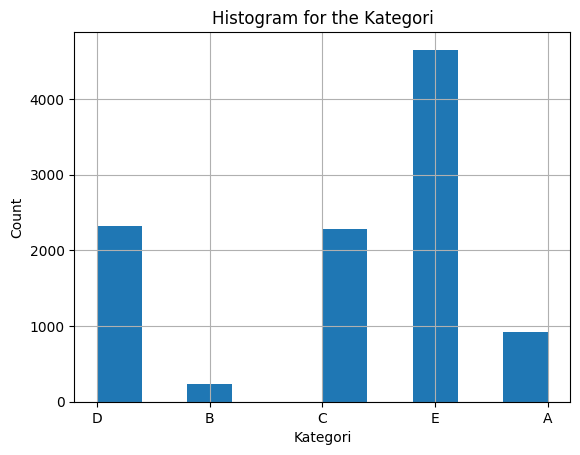

In [49]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
# y.value_counts().plot(kind='bar')
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [50]:
distinct_classes_df = data.drop_duplicates(subset=['Kategori'])
distinct_classes_df

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.000000,-2.000000,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.000000,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-3.656751e-01,-0.705532,417.95,38.81,38.7,38.9,0.087560,-0.188430,-1.526150,349.30,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
493,89.0,42.0,43.0,109.0,91.0,45.0,544.0,259.0,539.0,356.0,49.9,40.5,TR610,TR610_1,3.0,33,3.0,3.5,2.9,B,Baik,88.7,88.0,90,0.674949,0.365675,-0.705532,797.5,42.6,42,43,0.516398,-0.408248,-1.833333,383.5,42.4,41,43,0.699206,-0.657843,-0.628099,381.5,109.5,109,110.0,0.527046,0.000000,-2.000000,986.0,92.1,91,93,0.737865,-0.139942,-0.960433,829.5,45.4,44,47,0.843274,0.328125,-0.335937,409.0,544.7,544,545,0.483046,-0.872872,-1.238095,4902.5,260.0,259.0,261,0.816497,0.000000,-1.333333,2340.5,539.6,538,540,0.699206,-1.397916,0.611570,4856.5,356.4,355,357,0.843274,-0.843750,-0.921875,3207.5,49.80,49.7,49.9,0.066667,1.685131e-13,-0.500000,448.20,40.43,40.4,40.5,0.048305,0.872872,-1.238095,363.85,3.0,3.0,3.0,0.000000e+00,27.0,33,33,33,0,297,3.0,3.0,3.0,0.000000e+00,27.0,3.5,3.5,3.5,0.000000e+00,31.5,2.9,2.9,2.9,4.681111e-16,26.1
622,83.0,39.0,41.0,87.0,84.0,44.0,541.0,206.0,536.0,330.0,49.0,39.8,TR619,TR619_1,2.6,32,2.7,2.8,2.6,C,Cacat Mutu,84.2,83.0,85,0.632456,-0.111111,-0.444444,758.5,40.3,39,42,0.823273,0.680065,0.154260,363.5,40.4,39,42,0.966092,-0.093522,-0.897959,362.5,87.2,87,88.0,0.421637,1.500000,0.250000,785.0,84.9,84,86,0.875595,0.188430,-1.526150,764.5,43.0,42,44,0.942809,0.000000,-1.750000,386.0,540.6,539,541,0.699206,-1.397916,0.611570,4865.5,206.5,206.0,207,0.527046,0.000000,-2.000000,1858.5,535.7,535,537,0.823273,0.579314,-1.135716,4821.5,330.9,330,332,0.737865,0.139942,-0.960433,2978.5,48.90,48.8,49.0,0.081650,9.331327e-17,-1.333333,440.10,39.71,39.7,39.8,0.031623,2.666667,5.111111,357.35,2.6,2.6,2.6,4.681111e-16,23.4,32,32,32,0,288,2.7,2.7,2.7,4.681111e-16,24.3,2.8,2.8,2.8,4.681111e-16,25.2,2.6,2.6,2.6,4.681111e-16,23.4
807,84.0,39.0,40.0,78.0,84.0,41.0,542.0,207.0,538.0,337.0,

In [51]:
X = data[feature_cols]
y = data[target_cols]


cat_features = [
    i for i, col in enumerate(X.columns)
    if X[col].dtype == 'object'
]

print(X.shape, y.shape)

(10409, 12) (10409,)


In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded

array([3, 3, 3, ..., 4, 4, 4], shape=(10409,))

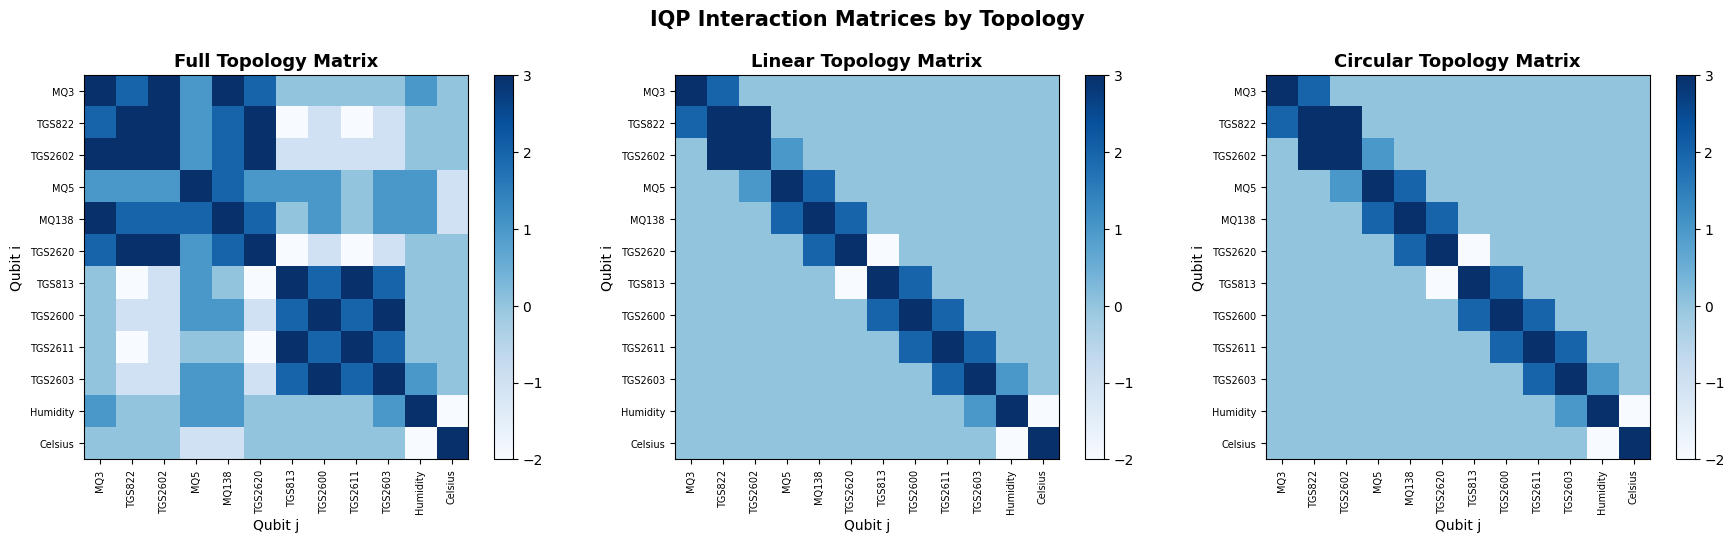

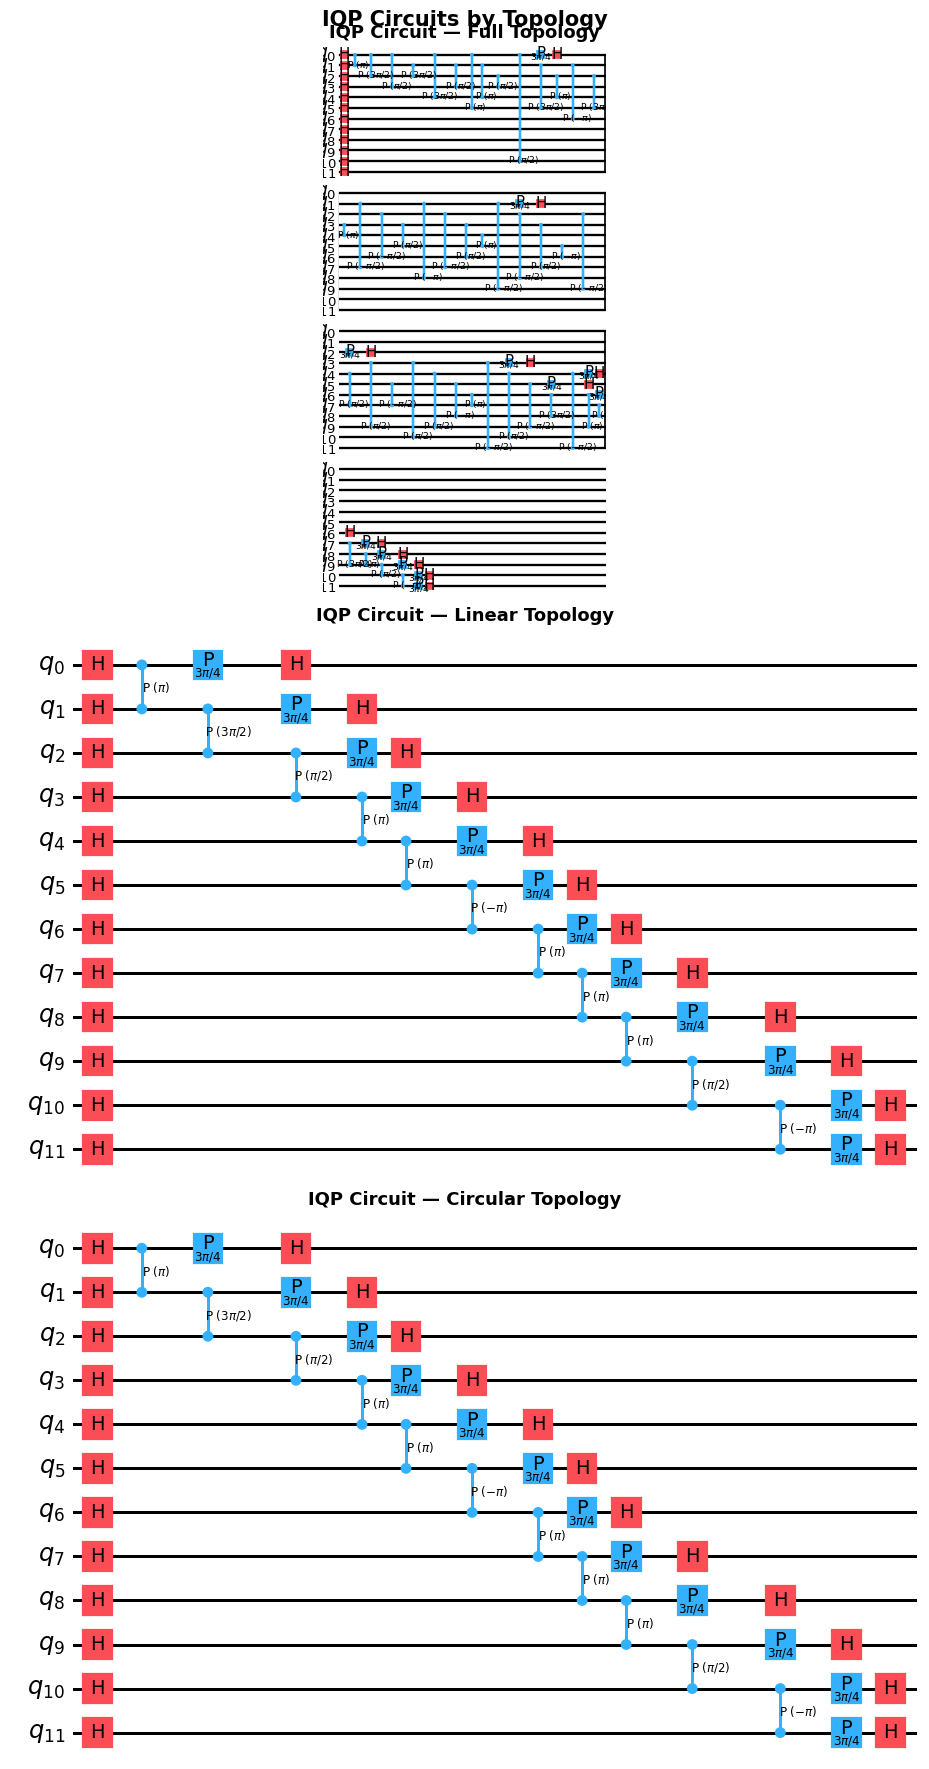

In [56]:
from qiskit.circuit.library import iqp
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import circuit_drawer

n = len(feature_cols)

corr_matrix = X.corr().to_numpy() 
scale = 3  # adjust scale as needed
base_matrix = np.round(X.corr().to_numpy() * scale).astype(int)

def build_full(matrix):
    """Use full correlation matrix as-is"""
    return matrix.copy()

def build_linear(matrix, n):
    """Keep only diagonal + adjacent off-diagonal"""
    result = np.zeros((n, n), dtype=int)
    for i in range(n):
        result[i][i] = matrix[i][i]  # diagonal
    for i in range(n - 1):
        result[i][i+1] = matrix[i][i+1]
        result[i+1][i] = matrix[i+1][i]  # symmetric
    return result

def build_circular(matrix, n):
    """Linear + wrap-around connection"""
    result = build_linear(matrix, n).copy()
    result[0][n-1] = matrix[0][n-1]
    result[n-1][0] = matrix[n-1][0]  # symmetric
    return result

full_matrix     = build_full(base_matrix)
linear_matrix   = build_linear(base_matrix, n)
circular_matrix = build_circular(base_matrix, n)

circuit_full     = iqp(full_matrix)
circuit_linear   = iqp(linear_matrix)
circuit_circular = iqp(circular_matrix)

# ── 1. Plot interaction matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles   = ['Full', 'Linear', 'Circular']
matrices = [full_matrix, linear_matrix, circular_matrix]

for ax, title, mat in zip(axes, titles, matrices):
    im = ax.imshow(mat, cmap='Blues')
    ax.set_title(f'{title} Topology Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Qubit j')
    ax.set_ylabel('Qubit i')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
    ax.set_yticklabels(feature_cols, fontsize=7)
    plt.colorbar(im, ax=ax)

plt.suptitle('IQP Interaction Matrices by Topology', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('iqp_matrices.png', bbox_inches='tight')
plt.show()

# ── 2. Plot circuits ──────────────────────────────────────────────────────────
circuits = [circuit_full, circuit_linear, circuit_circular]

fig, axes = plt.subplots(3, 1, figsize=(20, 18))

for ax, title, circuit in zip(axes, titles, circuits):
    circuit_drawer(circuit, output='mpl', ax=ax)
    ax.set_title(f'IQP Circuit — {title} Topology', fontsize=13, fontweight='bold')

plt.suptitle('IQP Circuits by Topology', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('iqp_circuits.png', bbox_inches='tight')
plt.show()